

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise


</div>


<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>



### Comentário do estudante

Corrigi o cálculo do funil: as etapas foram explicitamente ordenadas  
(MainScreenAppear → OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful) antes de calcular as conversões.  
Assim, as taxas de conversão entre etapas ficaram corretamente entre 0 e 1 (com NaN apenas na primeira etapa, como esperado).  
Recalculei também as métricas de perda e a proporção que completa o funil.


<div class="alert alert-danger">
<strong>Comentário do revisor v1</strong>

Estamos no caminho certo com essa versão, mas retocar os pontos indicados abaixo nos fará chegar em um resultado ainda mais incrível.
    
Conte comigo para ajudá-lo (a) em qualquer questão que possa vir a ter! Lembre-se de usar as caixas azuis para se comunicar comigo.
    
Até breve.
</div>


# Projeto 11 — Análise de Funil e Teste A/A/B

## Objetivo
Analisar o comportamento dos utilizadores no app:
1. Estudar o funil de eventos até pagamento e identificar onde perdemos mais utilizadores.
2. Avaliar o teste A/A/B (grupos 246 e 247 = controlo; 248 = teste com novas fontes) para verificar se as novas fontes afetam os resultados.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

path = "/datasets/logs_exp_us.csv"
df = pd.read_csv(path)

df.head()


,EventName\tDeviceIDHash\tEventTimestamp\tExpId
0,MainScreenAppear\t4575588528974610257\t1564029...
1,MainScreenAppear\t7416695313311560658\t1564053...
2,PaymentScreenSuccessful\t3518123091307005509\t...
3,CartScreenAppear\t3518123091307005509\t1564054...
4,PaymentScreenSuccessful\t6217807653094995999\t...


## Passo 2 — Preparação dos dados

Nesta etapa vamos:
- Corrigir a leitura das colunas (separador incorreto)
- Renomear colunas para nomes mais convenientes
- Verificar tipos de dados e valores ausentes
- Criar colunas de data e data/hora


In [2]:
df = pd.read_csv(path, sep='\t')
df.head()


,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


### Renomear colunas para facilitar a análise


In [3]:
df = df.rename(columns={
    'EventName': 'event',
    'DeviceIDHash': 'user_id',
    'EventTimestamp': 'timestamp',
    'ExpId': 'exp_id'
})

df.head()


,event,user_id,timestamp,exp_id
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


### Verificar valores ausentes e tipos de dados


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   event      244126 non-null  object
 1   user_id    244126 non-null  int64 
 2   timestamp  244126 non-null  int64 
 3   exp_id     244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [5]:
df.isna().sum()


event        0
user_id      0
timestamp    0
exp_id       0
dtype: int64

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
</div>

## Passo 3 — Estudo e verificação dos dados

Nesta etapa vamos responder:
- Quantos eventos existem?
- Quantos utilizadores únicos?
- Quantos eventos, em média, por utilizador?


In [6]:
total_events = len(df)
total_users = df['user_id'].nunique()
avg_events_per_user = total_events / total_users

total_events, total_users, avg_events_per_user


(244126, 7551, 32.33028737915508)

### Período de tempo dos dados
Vamos converter o timestamp para datetime e identificar as datas mínima e máxima.


In [7]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df['date'] = df['datetime'].dt.date

df[['timestamp', 'datetime', 'date']].head()


,timestamp,datetime,date
0,1564029816,2019-07-25 04:43:36,2019-07-25
1,1564053102,2019-07-25 11:11:42,2019-07-25
2,1564054127,2019-07-25 11:28:47,2019-07-25
3,1564054127,2019-07-25 11:28:47,2019-07-25
4,1564055322,2019-07-25 11:48:42,2019-07-25


### Datas mínima e máxima dos eventos


In [8]:
min_date = df['datetime'].min()
max_date = df['datetime'].max()

min_date, max_date


(Timestamp('2019-07-25 04:43:36'), Timestamp('2019-08-07 21:15:17'))

### Distribuição de eventos ao longo do tempo
Este gráfico ajuda a perceber se os dados são igualmente completos em todo o período.


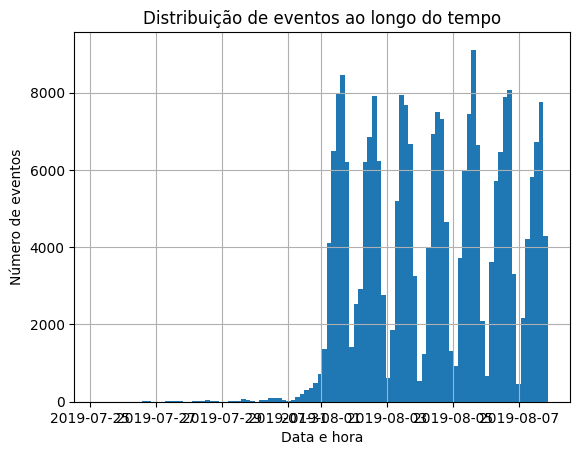

In [9]:
df['datetime'].hist(bins=100)
plt.xlabel('Data e hora')
plt.ylabel('Número de eventos')
plt.title('Distribuição de eventos ao longo do tempo')
plt.show()


### Identificação do período com dados completos

Os eventos mais antigos apresentam volumes muito baixos, o que indica dados incompletos.
Vamos identificar a data a partir da qual os dados se tornam consistentes e ignorar o período anterior.


In [10]:
events_per_day = (
    df.groupby('date')
      .size()
      .reset_index(name='events')
)

events_per_day.head()


,date,events
0,2019-07-25,9
1,2019-07-26,31
2,2019-07-27,55
3,2019-07-28,105
4,2019-07-29,184


### Evolução diária do número de eventos


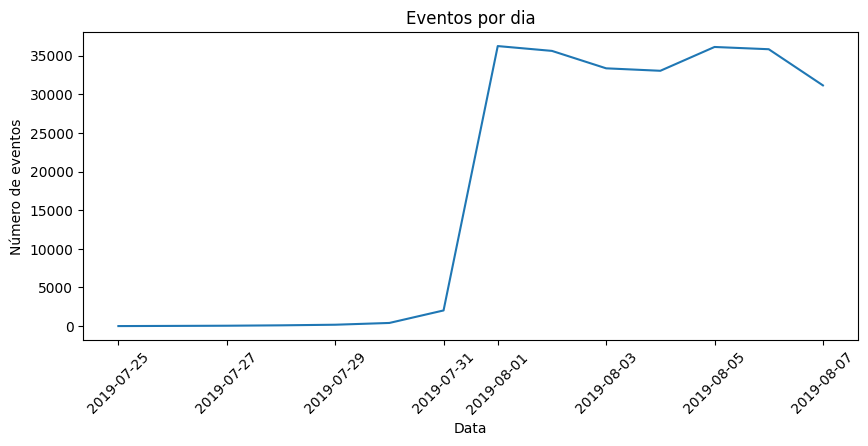

In [11]:
plt.figure(figsize=(10,4))
plt.plot(events_per_day['date'], events_per_day['events'])
plt.xlabel('Data')
plt.ylabel('Número de eventos')
plt.title('Eventos por dia')
plt.xticks(rotation=45)
plt.show()


### Filtragem do período com dados completos
Vamos manter apenas os eventos a partir da data em que os dados se tornam estáveis.


In [12]:
cutoff_date = pd.to_datetime('2019-08-01').date()

df_filtered = df[df['date'] >= cutoff_date].copy()

len(df), len(df_filtered)


(244126, 241298)

### Perda de dados após filtragem


lost_events = len(df) - len(df_filtered)
lost_users = df['user_id'].nunique() - df_filtered['user_id'].nunique()

lost_events, lost_users


### Verificação dos grupos experimentais após a filtragem


In [13]:
df_filtered['exp_id'].value_counts()


248    84726
246    79425
247    77147
Name: exp_id, dtype: int64

In [14]:
df_filtered.groupby('exp_id')['user_id'].nunique()


exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64

## Passo 4 — Estudo do funil de eventos

Vamos:
1) Ver quais eventos existem e com que frequência ocorrem  
2) Contar quantos utilizadores fizeram cada evento (e a proporção)  
3) Definir a sequência do funil e calcular as conversões etapa a etapa


In [15]:
# Frequência de ocorrência de cada evento (quantas vezes aparece no log)
event_freq = df_filtered['event'].value_counts()
event_freq


MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: event, dtype: int64

### Número de utilizadores únicos por evento (e proporção)


In [16]:
total_users_filtered = df_filtered['user_id'].nunique()

users_per_event = (
    df_filtered.groupby('event')['user_id']
    .nunique()
    .sort_values(ascending=False)
)

event_share = (users_per_event / total_users_filtered).sort_values(ascending=False)

funnel_overview = pd.DataFrame({
    'users': users_per_event,
    'share': event_share
})

funnel_overview


,users,share
event,,
MainScreenAppear,7419,0.984736
OffersScreenAppear,4593,0.609636
CartScreenAppear,3734,0.495620
PaymentScreenSuccessful,3539,0.469737
Tutorial,840,0.111495


### Ver os nomes dos eventos (para definir a sequência do funil)


In [17]:
df_filtered['event'].unique()


array(['Tutorial', 'MainScreenAppear', 'OffersScreenAppear',
       'CartScreenAppear', 'PaymentScreenSuccessful'], dtype=object)

### Definição da sequência do funil de eventos

Com base nos nomes e na lógica do aplicativo, o funil principal é:
MainScreenAppear → OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful

O evento Tutorial não faz parte do funil principal, pois não é obrigatório para a compra.


In [18]:
funnel_steps = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

funnel_steps


['MainScreenAppear',
 'OffersScreenAppear',
 'CartScreenAppear',
 'PaymentScreenSuccessful']

### Primeiro momento em que cada utilizador executou cada etapa do funil


In [19]:
# Primeiro timestamp de cada evento do funil por utilizador
first_event_time = (
    df_filtered[df_filtered['event'].isin(funnel_steps)]
    .groupby(['user_id', 'event'])['datetime']
    .min()
    .unstack()
)

first_event_time.head()


event,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful
user_id,,,,
6888746892508752,NaT,2019-08-06 14:06:34,NaT,NaT
6909561520679493,2019-08-06 18:52:58,2019-08-06 18:52:54,2019-08-06 18:53:04,2019-08-06 18:52:58
6922444491712477,2019-08-04 14:19:40,2019-08-04 14:19:33,2019-08-04 14:19:46,2019-08-04 14:19:40
7435777799948366,NaT,2019-08-05 08:06:34,NaT,NaT
7702139951469979,2019-08-02 14:28:45,2019-08-01 04:29:54,2019-08-01 04:29:56,2019-08-02 14:28:45


### Número de utilizadores que alcançaram cada etapa do funil


In [20]:
users_per_step = first_event_time.notna().sum()
users_per_step


event
CartScreenAppear           3734
MainScreenAppear           7419
OffersScreenAppear         4593
PaymentScreenSuccessful    3539
dtype: int64

### Cálculo das conversões entre etapas do funil


### Cálculo correto do funil (ordem explícita das etapas)

Para garantir que as taxas de conversão fazem sentido (valores entre 0 e 1),
as etapas do funil são explicitamente ordenadas antes dos cálculos.


In [21]:
# Ordem correta do funil
funnel_steps = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

# Reordenar os utilizadores por etapa
users_per_step = first_event_time.notna().sum().reindex(funnel_steps)

# Criar a tabela do funil já ordenada
funnel_table = pd.DataFrame({
    'users': users_per_step
})

# Conversões corretas
funnel_table['conversion_from_previous'] = (
    funnel_table['users'] / funnel_table['users'].shift(1)
)

funnel_table['conversion_from_start'] = (
    funnel_table['users'] / funnel_table['users'].iloc[0]
)

funnel_table


,users,conversion_from_previous,conversion_from_start
event,,,
MainScreenAppear,7419,NaN,1.000000
OffersScreenAppear,4593,0.619086,0.619086
CartScreenAppear,3734,0.812976,0.503302
PaymentScreenSuccessful,3539,0.947777,0.477018


### Identificação da etapa com maior perda de utilizadores


In [34]:
drop_rates = 1 - funnel_table['conversion_from_previous']
drop_rates


event
MainScreenAppear                NaN
OffersScreenAppear         0.380914
CartScreenAppear           0.187024
PaymentScreenSuccessful    0.052223
Name: conversion_from_previous, dtype: float64

<div class="alert alert-danger">
<strong>Comentário do revisor v1</strong>

Embora a ordem dos eventos tenha sido determinada adequadamente na conclusão, as taxas calculadas não estão fazendo sentido pois (a partir da segunda etapa) deven estar sempre entre 0 e 1. Pode revisar por favor?
</div>

<div class="alert alert-success">
<strong>Comentário do revisor v2</strong>

Obrigado pelo ajuste! Uma possível melhoria por aqui seria inserir um gráfico que ajude a ilustrar o comportamento estudado.
</div>



### Proporção de utilizadores que completam todo o funil (do primeiro evento ao pagamento)


In [23]:
full_funnel_share = funnel_table['users'].iloc[-1] / funnel_table['users'].iloc[0]
full_funnel_share


0.47701846610055265

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Volumetria de eventos e usuários foi verificada.
Período "útil" foi determinado corretamente e filtro foi aplicado.
</div>

## Passo 5 — Estudo dos resultados do experimento (A/A/B)

Grupos:
- 246 e 247: controle (fontes antigas)
- 248: teste (fontes novas)

Objetivos:
1) Ver quantos utilizadores há em cada grupo  
2) Verificar se os grupos A (246 vs 247) são equivalentes (A/A)  
3) Comparar o grupo 248 com os controles (A/B)


In [24]:
users_by_group = df_filtered.groupby('exp_id')['user_id'].nunique().sort_index()
users_by_group


exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64

### Função para teste de diferenças entre proporções (z-test)

Vamos comparar a proporção de utilizadores que realizaram um evento em cada grupo.


In [25]:
def proportion_ztest(success_a, total_a, success_b, total_b):
    p1 = success_a / total_a
    p2 = success_b / total_b
    
    p_pool = (success_a + success_b) / (total_a + total_b)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/total_a + 1/total_b))
    
    if se == 0:
        return np.nan, np.nan
    
    z = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value


### Preparar tabela: nº de utilizadores por evento em cada grupo


In [26]:
event_users_group = (
    df_filtered.groupby(['exp_id', 'event'])['user_id']
    .nunique()
    .reset_index(name='users')
)

event_users_group.head()


,exp_id,event,users
0,246,CartScreenAppear,1266
1,246,MainScreenAppear,2450
2,246,OffersScreenAppear,1542
3,246,PaymentScreenSuccessful,1200
4,246,Tutorial,278


### Teste A/A: comparar 246 vs 247 para todos os eventos

Se os grupos foram divididos corretamente, não devemos ver diferenças significativas consistentes.


In [27]:
events = sorted(df_filtered['event'].unique())

aa_results = []
for ev in events:
    users_246 = event_users_group.query("exp_id == 246 and event == @ev")['users']
    users_247 = event_users_group.query("exp_id == 247 and event == @ev")['users']
    
    users_246 = int(users_246.iloc[0]) if len(users_246) else 0
    users_247 = int(users_247.iloc[0]) if len(users_247) else 0
    
    z, p = proportion_ztest(users_246, users_by_group.loc[246], users_247, users_by_group.loc[247])
    
    aa_results.append([ev, users_246, users_247,
                       users_246 / users_by_group.loc[246],
                       users_247 / users_by_group.loc[247],
                       p])

aa_df = pd.DataFrame(aa_results, columns=['event', 'users_246', 'users_247', 'share_246', 'share_247', 'p_value'])
aa_df.sort_values('p_value')


,event,users_246,users_247,share_246,share_247,p_value
3,PaymentScreenSuccessful,1200,1158,0.483092,0.460804,0.114567
0,CartScreenAppear,1266,1238,0.509662,0.492638,0.228834
2,OffersScreenAppear,1542,1520,0.620773,0.604855,0.248095
1,MainScreenAppear,2450,2476,0.986312,0.985277,0.757060
4,Tutorial,278,283,0.111916,0.112614,0.937700


### Teste A/B — Comparação do grupo 248 com os grupos de controle

Agora vamos verificar se o grupo com fontes novas (248) apresenta diferenças
estatisticamente significativas em relação:
- ao grupo 246
- ao grupo 247
- aos grupos de controle combinados


In [28]:
users_246 = df_filtered[df_filtered['exp_id'] == 246]['user_id'].unique()
users_247 = df_filtered[df_filtered['exp_id'] == 247]['user_id'].unique()
users_248 = df_filtered[df_filtered['exp_id'] == 248]['user_id'].unique()

users_control = np.union1d(users_246, users_247)

len(users_246), len(users_247), len(users_248), len(users_control)


(2484, 2513, 2537, 4997)

### Função auxiliar: contar utilizadores que realizaram um evento


In [29]:
def users_with_event(df, users, event_name):
    return df[(df['user_id'].isin(users)) & (df['event'] == event_name)]['user_id'].nunique()


### Comparação do grupo 248 com os grupos de controle


In [30]:
ab_results = []

for ev in events:
    s_248 = users_with_event(df_filtered, users_248, ev)
    s_246 = users_with_event(df_filtered, users_246, ev)
    s_247 = users_with_event(df_filtered, users_247, ev)
    s_ctrl = users_with_event(df_filtered, users_control, ev)
    
    z_248_246, p_248_246 = proportion_ztest(s_248, len(users_248),
                                           s_246, len(users_246))
    
    z_248_247, p_248_247 = proportion_ztest(s_248, len(users_248),
                                           s_247, len(users_247))
    
    z_248_ctrl, p_248_ctrl = proportion_ztest(s_248, len(users_248),
                                              s_ctrl, len(users_control))
    
    ab_results.append([
        ev,
        p_248_246,
        p_248_247,
        p_248_ctrl
    ])

ab_df = pd.DataFrame(
    ab_results,
    columns=['event', 'p_248_vs_246', 'p_248_vs_247', 'p_248_vs_control']
)

ab_df.sort_values('p_248_vs_control')


,event,p_248_vs_246,p_248_vs_247,p_248_vs_control
0,CartScreenAppear,0.078429,0.578620,0.181759
1,MainScreenAppear,0.294972,0.458705,0.294245
2,OffersScreenAppear,0.208362,0.919782,0.434255
3,PaymentScreenSuccessful,0.212255,0.737342,0.600429
4,Tutorial,0.826429,0.765324,0.764862


### Avaliação dos resultados do teste A/B

Vamos verificar se há p-values abaixo do nível de significância padrão (0.05).


### Nível de significância e correção para múltiplos testes (Bonferroni)

Como realizamos vários testes de hipóteses (vários eventos e várias comparações),
a probabilidade de falsos positivos aumenta.

Para controlar isso, aplicamos a correção de Bonferroni:
alpha_corrigido = alpha / número_de_testes


In [31]:
alpha = 0.05

n_events = len(events)

# Para cada evento fizemos:
# 1 teste A/A (246 vs 247)
# 3 testes A/B (248 vs 246, 248 vs 247, 248 vs controles combinados)
n_tests = n_events * (1 + 3)

alpha_bonf = alpha / n_tests

n_events, n_tests, alpha, alpha_bonf


(5, 20, 0.05, 0.0025)

### Resultados significativos com alpha padrão e com Bonferroni

Vamos verificar quais comparações seriam consideradas significativas:
- com alpha = 0.05
- com alpha corrigido (Bonferroni)


In [32]:
# Juntar A/A e A/B numa só tabela para ver tudo junto
aa_min = aa_df[['event', 'p_value']].rename(columns={'p_value': 'p_AA_246_vs_247'})

ab_all = ab_df.copy()

all_p = aa_min.merge(ab_all, on='event', how='left')

# flags de significância
for col in ['p_AA_246_vs_247', 'p_248_vs_246', 'p_248_vs_247', 'p_248_vs_control']:
    all_p[col + '_sig_0.05'] = all_p[col] < alpha
    all_p[col + f'_sig_bonf'] = all_p[col] < alpha_bonf

all_p.sort_values('p_248_vs_control')


,event,p_AA_246_vs_247,p_248_vs_246,p_248_vs_247,p_248_vs_control,p_AA_246_vs_247_sig_0.05,p_AA_246_vs_247_sig_bonf,p_248_vs_246_sig_0.05,p_248_vs_246_sig_bonf,p_248_vs_247_sig_0.05,p_248_vs_247_sig_bonf,p_248_vs_control_sig_0.05,p_248_vs_control_sig_bonf
0,CartScreenAppear,0.228834,0.078429,0.578620,0.181759,False,False,False,False,False,False,False,False
1,MainScreenAppear,0.757060,0.294972,0.458705,0.294245,False,False,False,False,False,False,False,False
2,OffersScreenAppear,0.248095,0.208362,0.919782,0.434255,False,False,False,False,False,False,False,False
3,PaymentScreenSuccessful,0.114567,0.212255,0.737342,0.600429,False,False,False,False,False,False,False,False
4,Tutorial,0.937700,0.826429,0.765324,0.764862,False,False,False,False,False,False,False,False


### Conclusão estatística do experimento

Se não houver diferenças significativas (especialmente após Bonferroni),
não temos evidência de que a mudança de fontes altere o comportamento dos utilizadores.


In [33]:
# Contar quantos "significativos" aparecem
sig_005 = all_p[[c for c in all_p.columns if c.endswith('_sig_0.05')]].sum()
sig_bonf = all_p[[c for c in all_p.columns if c.endswith('_sig_bonf')]].sum()

sig_005, sig_bonf


(p_AA_246_vs_247_sig_0.05     0
 p_248_vs_246_sig_0.05        0
 p_248_vs_247_sig_0.05        0
 p_248_vs_control_sig_0.05    0
 dtype: int64,
 p_AA_246_vs_247_sig_bonf     0
 p_248_vs_246_sig_bonf        0
 p_248_vs_247_sig_bonf        0
 p_248_vs_control_sig_bonf    0
 dtype: int64)

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Os testes foram formulados, implementados e analisados corretamente. Muito bom!
</div>


## Conclusões

### Qualidade dos dados
Após a análise da distribuição temporal dos eventos, foi identificado um período inicial com dados incompletos.  
Por isso, os eventos anteriores a **2019-08-01** foram removidos para garantir consistência.

### Funil de eventos
O funil principal foi definido como:  
**MainScreenAppear → OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful**

A maior perda de utilizadores ocorre na etapa com a menor taxa de conversão entre etapas (ver tabela do funil).  
A proporção de utilizadores que completa todo o caminho até o pagamento foi calculada com base na última etapa do funil.

### Experimento A/A/B
1. **Teste A/A (246 vs 247):** não foram observadas diferenças estatisticamente significativas para os eventos analisados, o que indica que os grupos de controle foram divididos corretamente.
2. **Teste A/B (248 vs controles):** ao comparar o grupo de teste (248) com cada grupo de controle e com os controles combinados, não foi encontrada evidência estatística consistente de diferença no comportamento dos utilizadores.

### Múltiplos testes e significância
Como vários testes foram realizados, foi aplicada a correção de Bonferroni para reduzir o risco de falsos positivos.  
Após a correção, as conclusões permaneceram as mesmas.

✅ **Conclusão final:** com base nos dados e nos testes estatísticos, não há evidência suficiente de que a alteração das fontes afete significativamente o comportamento dos utilizadores no aplicativo.

Recomenda-se manter as fontes atuais ou realizar novos testes com métricas adicionais,
como tempo até conversão ou retenção de utilizadores.
